# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків -
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` - спостереження космічної погоди
за 28 серпня - 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен - відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок - це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` - об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали - три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` - назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** - так ви побачите ноутбук очима викладача.
* Текстові клітинки - не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** - воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Козак Наталія'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 6     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки - у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Козак Наталія, ШІ-34, варіант 6
ваш потік:                   P>30
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      У яку добу середнє значення вашого потоку було найбільшим? А найменшим?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

MY_FILE = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом - `pd.read_excel(ФАЙЛ)` -
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
df = pd.read_excel(MY_FILE)
print(df.head())
df.info()

   Unnamed: 0        ftp://ftp.swpc.noaa.gov/pub/lists/particle/ Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12  \
0         NaN                                                NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
1         NaN                :Data_list: 20170901_Gs_part_5m.txt        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
2         NaN                     :Created: 2017 Sep 02 0011 UTC        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
3         NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
4         NaN  # Please send comments an

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

бо pandas читає все як одну велику таблицю: перші рядки, як заголовок, відповідно майже всі Unnamed, і пусті клітинки - Nan

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(MY_FILE, header=None)
print(RAW.shape)
print(RAW.head(30))

(7226, 32)
    0                                                  1    2    3     4         5        6      7      8      9       10      11      12     13     14  15  \
0  NaN        ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
1  NaN                                                NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
2  NaN                :Data_list: 20170901_Gs_part_5m.txt  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
3  NaN                     :Created: 2017 Sep 02 0011 UTC  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
4  NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
5  NaN  # Please send comments and 

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
print(RAW.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

три таблиці: 2-15, 17-20, 25-32 - нумерація з одиниці

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків - це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
for col in [1, 16, 26]:
    print(f"\nColumn {col}:")
    for index, value in RAW.iloc[:, col].dropna().head(20).items():
        print(f"{index}: {value}")


Column 1:
0: ftp://ftp.swpc.noaa.gov/pub/lists/particle/
2: :Data_list: 20170901_Gs_part_5m.txt
3: :Created: 2017 Sep 02 0011 UTC
4: # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
5: # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
6: # 
7: # Label: P > 1 = Particles at >1 Mev
8: # Label: P > 5 = Particles at >5 Mev
9: # Label: P >10 = Particles at >10 Mev
10: # Label: P >30 = Particles at >30 Mev
11: # Label: P >50 = Particles at >50 Mev
12: # Label: P>100 = Particles at >100 Mev
13: # Label: E>0.8 = Electrons at >0.8 Mev
14: # Label: E>2.0 = Electrons at >2.0 Mev
15: # Label: E>4.0 = Electrons at >4.0 Mev
16: # Units: Particles = Protons/cm2-s-sr
17: # Units: Electrons = Electrons/cm2-s-sr
18: # Source: GOES-15
19: # Location: W135
20: # Missing data: -1.00e+05

Column 16:
13: ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
15: Product: Daily Solar Data         quar_DSD.txt
16: :Issued: 0825 UT 04 Oct 2017
17: #
18: #

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | GOES-15 | Particles = Protons/cm2-s-sr, Electrons = Electrons/cm2-s-sr |
| B | Space Weather Prediction Center | - |
| C | SOHO CELIAS Proton Monitor | Proton speed [km/sec], Proton density [protons per cubic centimeter], |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить - решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B-O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q-T | добовий показник сонячної активності F10.7 | доба |
| C | Y-AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` - назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
A = RAW.iloc[26:, 1:15].copy()
B = RAW.iloc[27:, 16:20].copy()
C = RAW.iloc[27:, 24:32].copy()

A.columns = ['year', 'month', 'day', 'hhmm', 'modified_julian_day',
             'seconds_of_day', 'P>1', 'P>5', 'P>10', 'P>30',
             'P>50', 'P>100', 'E>0.8', 'E>2.0']
B.columns = ['year', 'month', 'day', 'F10.7']
C.columns = ['hour_1', 'hour_2', 'year', 'month', 'day',
             'hour', 'speed_km_s', 'density_protons_cm3']

A = A.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)
B = B.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)
C = C.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)

for name, table in [('A', A), ('B', B), ('C', C)]:
    print(f'Таблиця {name}: {table.shape}')
    print(table.head())


Таблиця A: (7200, 14)
   year  month  day  hhmm  modified_julian_day  seconds_of_day    P>1    P>5   P>10    P>30    P>50   P>100    E>0.8   E>2.0
0  2017      8   28     0                57993               0  12.00  0.260  0.180  0.1140  0.1040  0.0793  23600.0  1180.0
1  2017      8   28     5                57993             300  19.40  0.690  0.314  0.1120  0.0612  0.0251  23100.0  1160.0
2  2017      8   28    10                57993             600   8.48  0.168  0.130  0.0717  0.0614  0.0304  22200.0  1090.0
3  2017      8   28    15                57993             900  15.40  0.566  0.198  0.0926  0.0568  0.0251  20400.0   997.0
4  2017      8   28    20                57993            1200   6.41  0.156  0.118  0.0597  0.0494  0.0251  18500.0   875.0
Таблиця B: (25, 4)
     year  month   day  F10.7
0  2017.0    8.0  28.0   82.0
1  2017.0    8.0  29.0   84.0
2  2017.0    8.0  30.0   87.0
3  2017.0    8.0  31.0   92.0
4  2017.0    9.0   1.0   93.0
Таблиця C: (601, 8)
   hour_1

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня-вересня 2017 року.
Якщо у вас вийшов інший рік - придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
# A: час записаний як hhmm, наприклад 1235 означає 12:35
A['ts'] = pd.to_datetime(A[['year', 'month', 'day']])
A['ts'] += pd.to_timedelta(A['hhmm'] // 100, unit='h')
A['ts'] += pd.to_timedelta(A['hhmm'] % 100, unit='m')

# B: є тільки дата, тому час буде 00:00
B['ts'] = pd.to_datetime(B[['year', 'month', 'day']])

# C: рік записаний як 17, тому додаю 2000
C['ts'] = pd.to_datetime(C[['year', 'month', 'day']].assign(year=C['year'] + 2000))
C['ts'] += pd.to_timedelta(C['hour'], unit='h')

for name, table in [('A', A), ('B', B), ('C', C)]:
    print(f"Таблиця {name}: від {table['ts'].min()} до {table['ts'].max()}")


Таблиця A: від 2017-08-28 00:00:00 до 2017-09-21 23:55:00
Таблиця B: від 2017-08-28 00:00:00 до 2017-09-21 00:00:00
Таблиця C: від 2017-08-28 00:00:00 до 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 - перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for name, table in [('A', A), ('B', B), ('C', C)]:
    print(f'\nТаблиця {name}')
    print('Розмір:', table.shape)
    print('\nТипи стовпців:')
    print(table.dtypes)
    print('\nКількість пропусків:')
    print(table.isna().sum())
    print('\nКількість повних дублікатів:', table.duplicated().sum())
    print('\nОписова статистика:')
    print(table.describe())



Таблиця A
Розмір: (7200, 15)

Типи стовпців:
year                            int64
month                           int64
day                             int64
hhmm                            int64
modified_julian_day             int64
seconds_of_day                  int64
P>1                           float64
P>5                           float64
P>10                          float64
P>30                          float64
P>50                          float64
P>100                         float64
E>0.8                         float64
E>2.0                         float64
ts                     datetime64[ns]
dtype: object

Кількість пропусків:
year                   0
month                  0
day                    0
hhmm                   0
modified_julian_day    0
seconds_of_day         0
P>1                    3
P>5                    3
P>10                   3
P>30                   3
P>50                   3
P>100                  3
E>0.8                  3
E>2.0                  

### Завдання 3.2 - дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина - фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
for col in ['speed_km_s', 'density_protons_cm3']:
    negative = C[col] < 0
    print(f'\nСтовпець: {col}')
    print('Кількість від’ємних значень:', negative.sum())
    print('Які це значення:', C.loc[negative, col].unique())

    before = C[col].agg(['mean', 'min'])
    C.loc[negative, col] = np.nan
    after = C[col].agg(['mean', 'min'])

    print(pd.DataFrame({'До заміни': before, 'Після заміни': after}))



Стовпець: speed_km_s
Кількість від’ємних значень: 8
Які це значення: [-1.]
       До заміни  Після заміни
mean  506.547421    513.394604
min    -1.000000    277.000000

Стовпець: density_protons_cm3
Кількість від’ємних значень: 8
Які це значення: [-1.]
      До заміни  Після заміни
mean   2.907654      2.960371
min   -1.000000      0.100000


**Відповідь 3.2:**

У швидкості та густині є по 8 від’ємних значень, усі вони дорівнюють -1. У службовому описі пропуски позначені як -1.00e+05 (тобто -100000), але в самій таблиці C стоїть -1. Отже, опис і дані не збігаються. Оскільки швидкість і густина не можуть бути від’ємними, ці значення вважаємо пропусками та замінюємо на NaN.

Після заміни середня швидкість зросла з 506.55 до 513.39 км/с, а мінімальна - з -1 до 277 км/с. Середня густина зросла з 2.91 до 2.96 протонів/см³, а мінімальна - з -1 до 0.1 протонів/см³. Від’ємні значення занижували середнє, бо враховувалися як справжні вимірювання. Після заміни pandas не враховує NaN під час обчислення середнього та мінімуму.

### Завдання 3.3 - питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника - на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
time_columns = ['year', 'month', 'day', 'hhmm',
                'modified_julian_day', 'seconds_of_day']
print(A[time_columns].describe())


         year        month          day         hhmm  modified_julian_day  seconds_of_day
count  7200.0  7200.000000  7200.000000  7200.000000          7200.000000     7200.000000
mean   2017.0     8.840000    13.960000  1177.500000         58005.000000    43050.000000
std       0.0     0.366632     8.775483   692.481902             7.211603    24943.113498
min    2017.0     8.000000     1.000000     0.000000         57993.000000        0.000000
25%    2017.0     9.000000     7.000000   588.750000         57999.000000    21525.000000
50%    2017.0     9.000000    13.000000  1177.500000         58005.000000    43050.000000
75%    2017.0     9.000000    19.000000  1766.250000         58011.000000    64575.000000
max    2017.0     9.000000    31.000000  2355.000000         58017.000000    86100.000000


**Відповідь 3.3:**

Це `year`, `month`, `day` і `hhmm`. Вони записані числами, але показують, коли зробили вимірювання. Наприклад, середнє між серпнем (8) і вереснем (9) - 8.5, але такого місяця немає. Середній номер дня теж мало що пояснює, бо 1 вересня йде після 31 серпня, хоча число 1 менше за 31.

З `hhmm` це ще помітніше: між 09:50 і 10:10 середній час - 10:00, а середнє чисел 950 і 1010 дорівнює 980. Виходить 09:80 - такого часу взагалі немає. Середнє року тут просто буде 2017, а стандартне відхилення - 0, бо всі записи за один рік. Про космічну погоду це нічого не говорить.

`modified_julian_day` і `seconds_of_day` теж описують час, а не потоки частинок. Для них середнє можна обчислити й пояснити як середній момент часу, але для аналізу самих вимірювань воно тут не потрібне. Корисніше подивитися початок і кінець спостережень через `ts`.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один - це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` - `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
flows = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_hourly = A.set_index('ts')[flows].resample('h').agg(['mean', 'max'])

A_hourly.columns = [f'{flow}_{stat}' for flow, stat in A_hourly.columns]
A_hourly = A_hourly.reset_index()

print('Розмір погодинної таблиці:', A_hourly.shape)
print(A_hourly.head())


Розмір погодинної таблиці: (600, 17)
                   ts  P>1_mean  P>1_max  P>5_mean  P>5_max  P>10_mean  P>10_max  P>30_mean  P>30_max  P>50_mean  P>50_max  P>100_mean  P>100_max    E>0.8_mean  E>0.8_max   E>2.0_mean  E>2.0_max
0 2017-08-28 00:00:00  9.778333    19.40  0.324917    0.690   0.192917     0.314   0.098850    0.2240   0.077583    0.1780    0.040692     0.0793  20941.666667    23600.0  1011.583333     1180.0
1 2017-08-28 01:00:00  7.994167    13.60  0.291667    0.512   0.156583     0.259   0.072583    0.0919   0.058700    0.0798    0.029950     0.0471  18091.666667    20600.0   713.000000      907.0
2 2017-08-28 02:00:00  6.099167    10.80  0.283000    0.479   0.177667     0.321   0.084450    0.1210   0.069642    0.1110    0.035025     0.0595  14108.333333    15000.0   380.833333      475.0
3 2017-08-28 03:00:00  4.752500     7.76  0.236833    0.329   0.166333     0.244   0.087658    0.1800   0.068092    0.1390    0.035517     0.0818  12766.666667    13100.0   267.916667

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

                          min      max
ts                                    
2017-09-10 00:00:00    0.1030    0.292
2017-09-10 01:00:00    0.0729    0.156
2017-09-10 02:00:00    0.0860    0.180
2017-09-10 03:00:00    0.0579    0.196
2017-09-10 04:00:00    0.0596    0.280
2017-09-10 05:00:00    0.0576    0.176
2017-09-10 06:00:00    0.0925    0.319
2017-09-10 07:00:00    0.0975    0.373
2017-09-10 08:00:00    0.0990    0.327
2017-09-10 09:00:00    0.0727    0.209
2017-09-10 10:00:00    0.1190    0.164
2017-09-10 11:00:00    0.0977    0.181
2017-09-10 12:00:00    0.0975    0.151
2017-09-10 13:00:00    0.0975    0.254
2017-09-10 14:00:00    0.0576    0.179
2017-09-10 15:00:00    0.1020    0.193
2017-09-10 16:00:00    0.1420   64.500
2017-09-10 17:00:00   90.1000  217.000
2017-09-10 18:00:00  237.0000  356.000
2017-09-10 19:00:00  240.0000  309.000
2017-09-10 20:00:00  242.0000  275.000
2017-09-10 21:00:00  276.0000  324.000
2017-09-10 22:00:00  328.0000  377.000
2017-09-10 23:00:00  324.

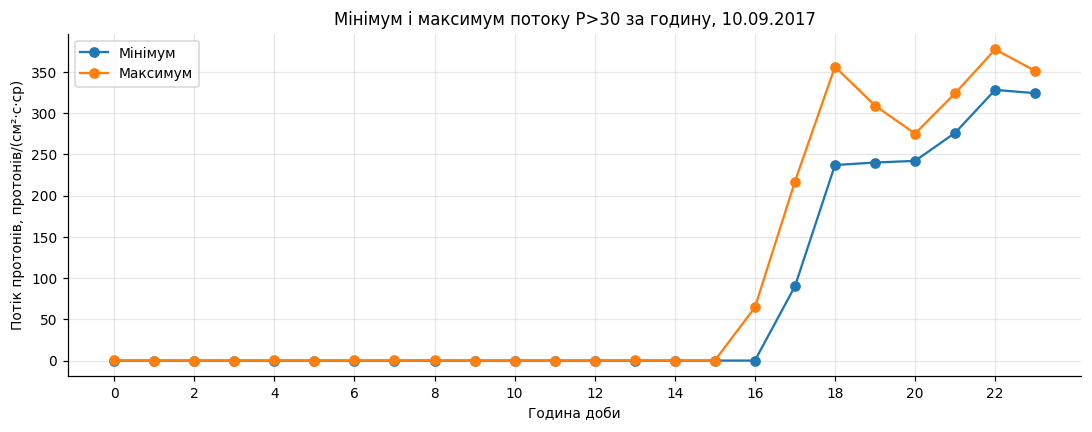

In [15]:
# Для варіанта 6 потік - P>30, агрегат - мінімум
flow = завдання['ваш потік']
day = A[(A['ts'] >= '2017-09-10') & (A['ts'] < '2017-09-11')]

comparison = day.set_index('ts')[flow].resample('h').agg(['min', 'max'])
print(comparison)

plt.figure(figsize=(10, 4))
plt.plot(comparison.index.hour, comparison['min'], label='Мінімум', marker='o')
plt.plot(comparison.index.hour, comparison['max'], label='Максимум', marker='o')
plt.title(f'Мінімум і максимум потоку {flow} за годину, 10.09.2017')
plt.xlabel('Година доби')
plt.ylabel('Потік протонів, протонів/(см²·с·ср)')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Відповідь 4.2:**

Для свого потоку P>30 я порівняла мінімум і максимум за 10 вересня. До 16:00 обидві криві на цьому масштабі майже біля нуля, а потім потік різко зростає. За годину з 16:00 до 17:00 мінімум становить 0.142, а максимум - 64.5. Тобто навіть у межах однієї години значення дуже змінилися.

Мінімум показує найменше значення за годину, а максимум - найбільше. Різниця між ними особливо важлива під час різкого зростання або короткого сплеску: якщо дивитися тільки на мінімум, можна не помітити високих значень. Але й максимум не означає, що такий потік тримався всю годину.

### Завдання 4.3
Об'єднайте три таблиці в одну - назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
B_hourly = B.loc[B.index.repeat(24), ['ts', 'F10.7']].reset_index(drop=True)
B_hourly['ts'] += pd.to_timedelta(np.tile(np.arange(24), len(B)), unit='h')

C_hourly = C[['ts', 'speed_km_s', 'density_protons_cm3']]

M_inner = A_hourly.merge(C_hourly, on='ts', how='inner')
M_inner = M_inner.merge(B_hourly, on='ts', how='inner')

M_outer = A_hourly.merge(C_hourly, on='ts', how='outer')
M_outer = M_outer.merge(B_hourly, on='ts', how='outer')

print('Кількість рядків з inner:', len(M_inner))
print('Кількість рядків з outer:', len(M_outer))

M = M_outer.sort_values('ts').reset_index(drop=True)
print('Розмір M:', M.shape)

missing_rows = M[M.isna().any(axis=1)]
print('Рядків з пропусками:', len(missing_rows))
print(missing_rows.to_string(index=False))


Кількість рядків з inner: 600
Кількість рядків з outer: 601
Розмір M: (601, 20)
Рядків з пропусками: 9
                 ts  P>1_mean  P>1_max  P>5_mean  P>5_max  P>10_mean  P>10_max  P>30_mean  P>30_max  P>50_mean  P>50_max  P>100_mean  P>100_max   E>0.8_mean  E>0.8_max  E>2.0_mean  E>2.0_max  speed_km_s  density_protons_cm3  F10.7
2017-09-04 07:00:00  6.465833    10.10  0.262083    0.593   0.171500     0.294   0.085483     0.145   0.068558     0.134    0.031717     0.0523 90600.000000   100000.0 7410.833333     8950.0         NaN                  NaN  140.0
2017-09-04 08:00:00  4.010833     5.08  0.256000    0.432   0.195833     0.336   0.086625     0.145   0.070033     0.134    0.036492     0.0546 73483.333333    79300.0 5048.333333     5850.0         NaN                  NaN  140.0
2017-09-04 09:00:00  3.268333     4.42  0.303417    0.518   0.220333     0.302   0.105925     0.162   0.081975     0.134    0.046483     0.0765 60475.000000    68500.0 3715.833333     4480.0         NaN  

**Відповідь 4.3:**

З `inner` вийшло 600 рядків, а з `outer` - 601. Різниця в останній годині: у таблиці C є запис за 22 вересня о 00:00, а в A та B дані закінчуються 21 вересня. Я обрала `outer`, щоб не втрачати цей запис. Там, де даних немає, залишаються NaN. Значення F10.7 повторюється для кожної години своєї доби, бо це добовий показник.

У підсумку M має 601 рядок і 20 стовпців. Пропуски є в 9 рядках: у 8 годинах 4 вересня після заміни від’ємних значень у C та в останньому записі за 22 вересня, для якого немає потоків частинок і F10.7. `inner` теж залишає ці 8 годин з пропусками, бо він перевіряє збіг часу, а не наявність усіх вимірювань.

### Завдання 4.4 - поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі - питання не сьогоднішньої роботи.

In [17]:
M['група'] = pd.cut(
    M['P>10_max'],
    bins=[-np.inf, 10, 1000, np.inf],
    labels=['тиха', 'активна', 'дуже активна'],
    right=False
)

print('Кількість годин у кожній групі:')
print(M['група'].value_counts(sort=False))

print('Годин без групи:', M['група'].isna().sum())


Кількість годин у кожній групі:
група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64
Годин без групи: 1


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d - перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків - п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, - **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно -
> так і напишіть. Відсутність зв'язку - це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною - стовпчик біля нуля і порожньо далі - не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 18.831272835858584
Медіана: 0.137825
Годин із даними: 600


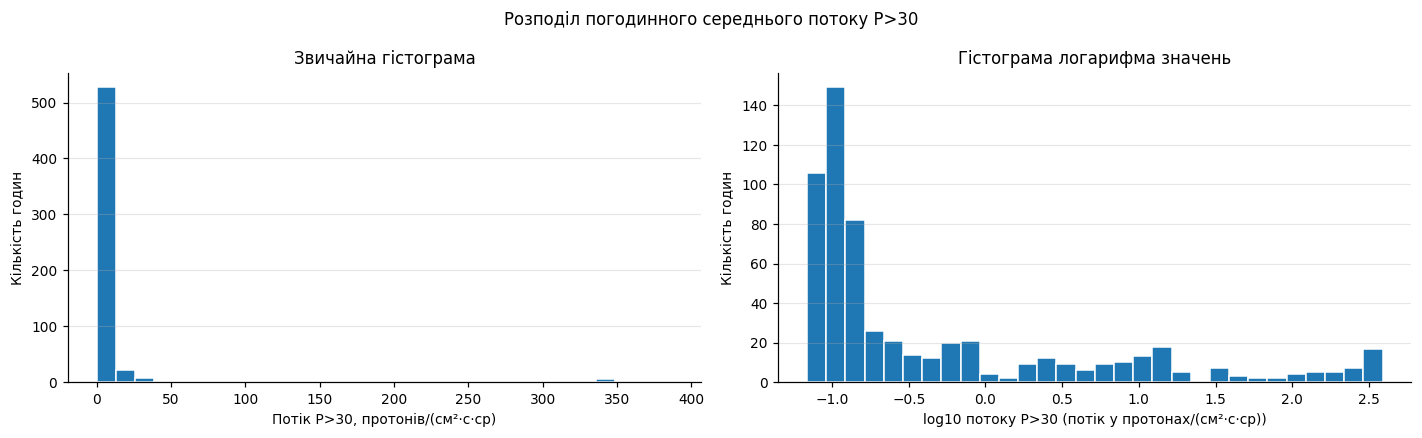

In [19]:
flow = завдання['ваш потік']
values = M[f'{flow}_mean'].dropna()

print('Середнє:', values.mean())
print('Медіана:', values.median())
print('Годин із даними:', len(values))

log_values = np.log10(values[values > 0])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Розподіл погодинного середнього потоку {flow}')

ax[0].hist(values, bins=30, edgecolor='white')
ax[0].set_title('Звичайна гістограма')
ax[0].set_xlabel(f'Потік {flow}, протонів/(см²·с·ср)')
ax[0].set_ylabel('Кількість годин')
ax[0].grid(axis='y', alpha=0.3)

ax[1].hist(log_values, bins=30, edgecolor='white')
ax[1].set_title('Гістограма логарифма значень')
ax[1].set_xlabel(f'log10 потоку {flow} (потік у протонах/(см²·с·ср))')
ax[1].set_ylabel('Кількість годин')
ax[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()


**Висновок:** Більшість погодинних значень потоку P>30 низькі, але є й значно вищі, які тягнуть середнє вгору, тому воно більше за медіану.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

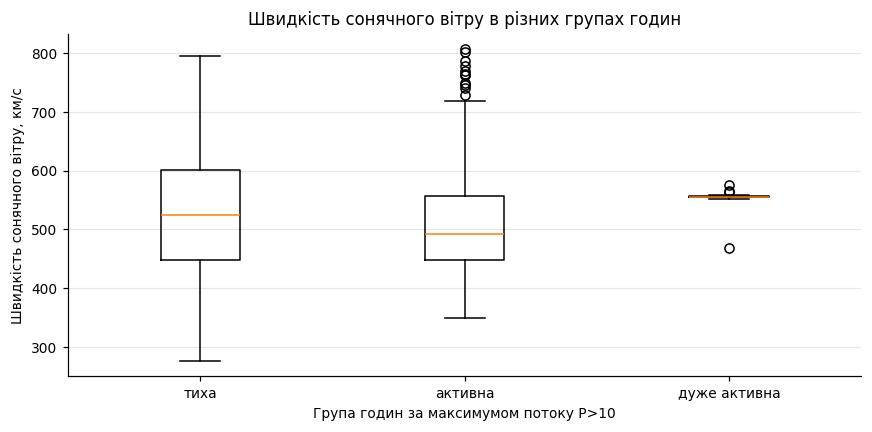

In [20]:
groups = ['тиха', 'активна', 'дуже активна']

speeds = [M.loc[M['група'] == group, 'speed_km_s'].dropna() for group in groups]

plt.figure(figsize=(8, 4))
plt.boxplot(speeds)
plt.xticks([1, 2, 3], groups)
plt.title('Швидкість сонячного вітру в різних групах годин')
plt.xlabel('Група годин за максимумом потоку P>10')
plt.ylabel('Швидкість сонячного вітру, км/с')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Висновок:** У дуже активні години більшість швидкостей зосереджена біля 550 км/с, а в тихі й активні години значення розкидані значно ширше, причому медіана в активній групі нижча, ніж у тихій.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції Пірсона: 0.28528892999766575


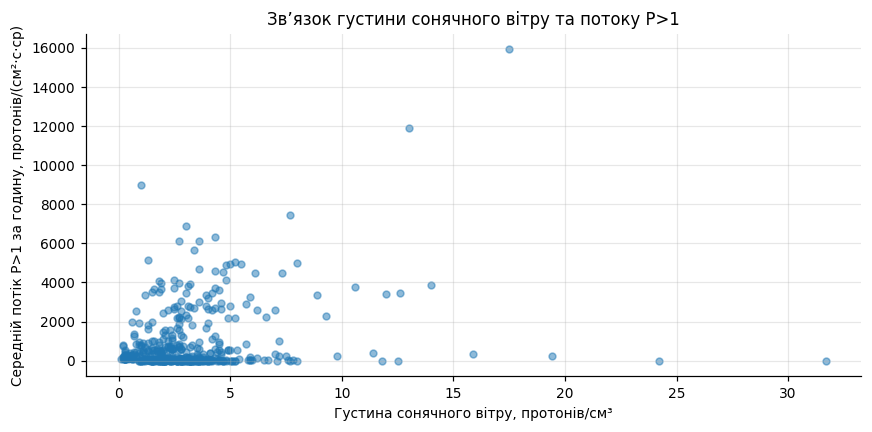

In [21]:
# Для варіанта 6 пара - густина вітру та потік P>1
pair = M[['density_protons_cm3', 'P>1_mean']].dropna()
correlation = pair['density_protons_cm3'].corr(pair['P>1_mean'])
print('Коефіцієнт кореляції Пірсона:', correlation)

plt.figure(figsize=(8, 4))
plt.scatter(pair['density_protons_cm3'], pair['P>1_mean'], alpha=0.5, s=20)
plt.title('Зв’язок густини сонячного вітру та потоку P>1')
plt.xlabel('Густина сонячного вітру, протонів/см³')
plt.ylabel('Середній потік P>1 за годину, протонів/(см²·с·ср)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Висновок:** Чіткого зв’язку між густиною вітру та потоком P>1 на графіку не видно: за схожої густини потік може бути як низьким, так і значно вищим.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

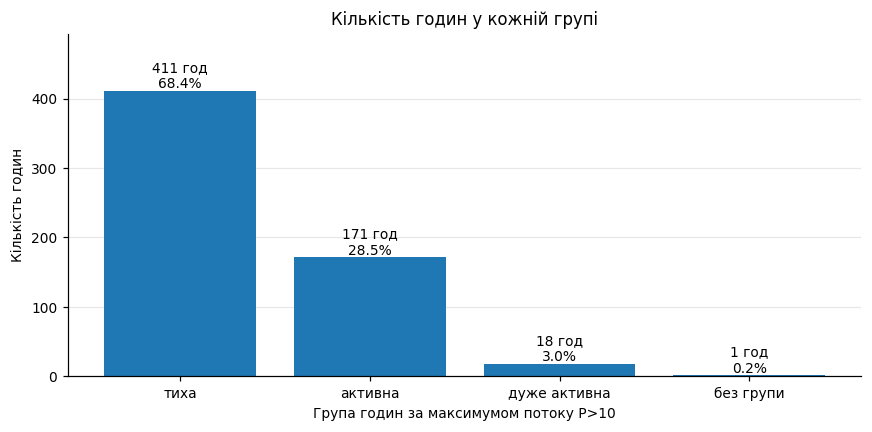

In [22]:
groups = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts().reindex(groups, fill_value=0)
# Враховуємо й години, для яких групу визначити не вдалося
counts.loc['без групи'] = M['група'].isna().sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values)
for bar, count in zip(bars, counts.values):
    percent = count / len(M) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, count,
            f'{count} год\n{percent:.1f}%', ha='center', va='bottom')

ax.set_title('Кількість годин у кожній групі')
ax.set_xlabel('Група годин за максимумом потоку P>10')
ax.set_ylabel('Кількість годин')
ax.set_ylim(0, counts.max() * 1.2)
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


**Висновок:** Більшість годин були тихими (68.4%), активні становили 28.5%, а дуже активні траплялися рідко - лише 3% часу.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною - згадайте, що допомогло в графіку 1.

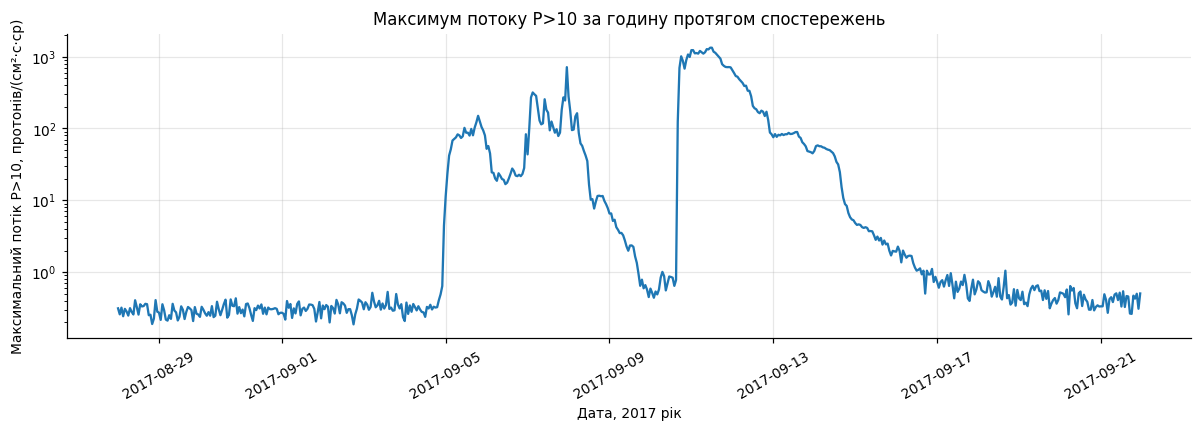

In [23]:
# Логарифмічна вісь дозволяє бачити і низькі значення, і сплески
plt.figure(figsize=(11, 4))
plt.plot(M['ts'], M['P>10_max'])
plt.yscale('log')
plt.title('Максимум потоку P>10 за годину протягом спостережень')
plt.xlabel('Дата, 2017 рік')
plt.ylabel('Максимальний потік P>10, протонів/(см²·с·ср)')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Висновок:** На початку спостережень потік P>10 був низьким, у вересні сталося кілька різких сплесків із найбільшим піком близько 11 вересня, після якого потік поступово повернувся до низьких значень.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** - це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

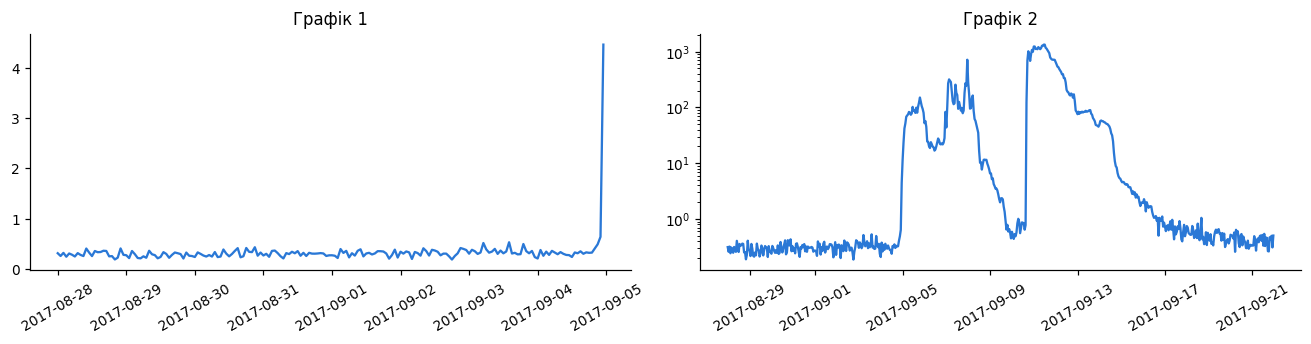

In [24]:
СТОВПЕЦЬ = 'P>10_max'   # максимум P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності -
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Людина, яка бачила тільки перший графік, подумає: «Космічна погода була спокійною, потік майже не змінювався, і лише наприкінці почалося різке зростання».

2. Людина, яка бачила тільки другий графік, подумає: «У вересні космічна погода була неспокійною: сталося кілька сильних сплесків, найбільший - близько 11 вересня, а потім потік поступово знизився».

3. Перша відмінність - період: перший графік показує тільки 28 серпня - 4 вересня, а другий - увесь період спостережень, тому основні сплески на перший просто не потрапили; друга відмінність - вісь Y: на першому вона звичайна, а на другому логарифмічна, що дозволяє одночасно бачити низькі значення й великі піки.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

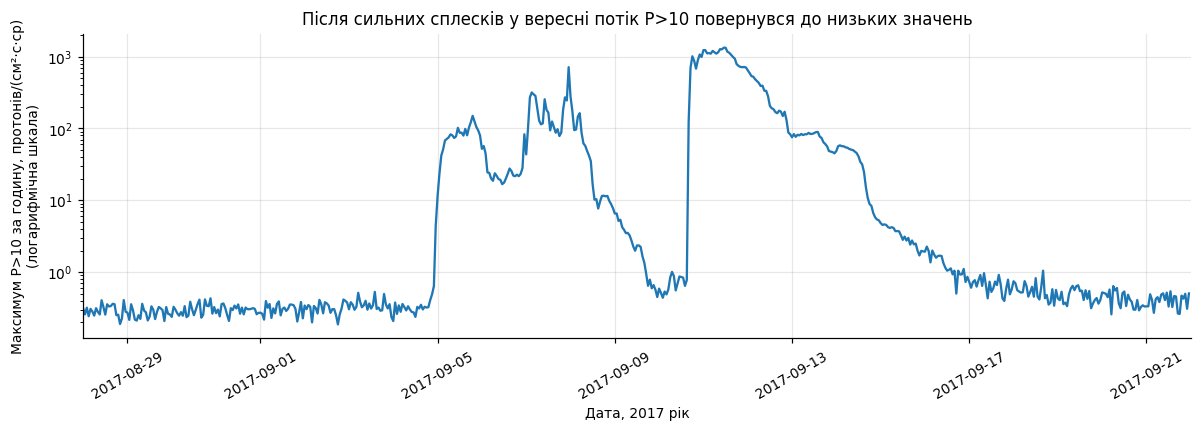

In [25]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(M['ts'], M['P>10_max'])
ax.set_yscale('log')
ax.set_xlim(M['ts'].min(), M['ts'].max())

ax.set_title('Після сильних сплесків у вересні потік P>10 повернувся до низьких значень')
ax.set_xlabel('Дата, 2017 рік')
ax.set_ylabel('Максимум P>10 за годину, протонів/(см²·с·ср)\n(логарифмічна шкала)')
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**Відповідь 6.2:**

Я взяла весь період спостережень, щоб було видно і спокійний початок, і сплески у вересні, і зниження потоку після них. Обрала лінійний графік, бо він показує, як потік змінювався з часом. Вісь Y зробила логарифмічною: значення відрізняються в тисячі разів, тому на звичайній шкалі низькі значення зливаються біля нуля. Тип шкали вказала в підписі осі, щоб було зрозуміло, що однакові відстані по вертикалі означають зміну в однакову кількість разів.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження - це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Середнє значення P>30 вийшло близько 18.83, а медіана - лише 0.138, тобто за одним середнім можна подумати, що потік зазвичай набагато вищий, ніж є насправді. На гістограмах видно, що більшість значень низькі, а середнє піднімають великі сплески. Це видно в етапі 5, на графіку 1 та в обчисленнях перед ним.

**Спостереження 2:** Дуже активні години не означають, що вітер тоді був найшвидшим: у цій групі швидкості переважно близькі до 550 км/с, а в тихій та активній трапляються значення близько 800 км/с. Тобто активність за потоком протонів і швидкість вітру - не одне й те саме. Це видно на графіку 2 етапу 5.

**Спостереження 3:** Тихих годин було найбільше - 68.4%, але це не означає, що весь період був спокійним: близько 11 вересня максимум P>10 за годину перевищував 1000 протонів/(см²·с·ср). Виходить, сильні сплески займали невелику частину часу, але дуже виділялися на тлі решти спостережень. Це видно на графіках 4 і 5 етапу 5.


### Завдання 7.2 - ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
# Моє питання: у яку добу середній потік був найбільшим і найменшим?
flow = завдання['ваш потік']

# Рахуємо добове середнє з погодинних середніх
daily_mean = M.set_index('ts')[f'{flow}_mean'].resample('D').mean().dropna()
max_day = daily_mean.idxmax()
min_day = daily_mean.idxmin()

print(f'Добові середні потоку {flow}, протонів/(см²·с·ср):')
print(daily_mean)
print(f'Найбільше: {max_day:%d.%m.%Y} - {daily_mean.loc[max_day]:.4f}')
print(f'Найменше: {min_day:%d.%m.%Y} - {daily_mean.loc[min_day]:.4f}')


Добові середні потоку P>30, протонів/(см²·с·ср):
ts
2017-08-28      0.092297
2017-08-29      0.091266
2017-08-30      0.094493
2017-08-31      0.092415
2017-09-01      0.089734
2017-09-02      0.090684
2017-09-03      0.098962
2017-09-04      0.106562
2017-09-05      0.650576
2017-09-06      1.555274
2017-09-07      4.723908
2017-09-08      2.247031
2017-09-09      0.168946
2017-09-10     82.230478
2017-09-11    292.930556
2017-09-12     64.703125
2017-09-13     13.776701
2017-09-14      5.486859
2017-09-15      0.660118
2017-09-16      0.278938
2017-09-17      0.140767
2017-09-18      0.136539
2017-09-19      0.121408
2017-09-20      0.109478
2017-09-21      0.104707
Freq: D, Name: P>30_mean, dtype: float64
Найбільше: 11.09.2017 - 292.9306
Найменше: 01.09.2017 - 0.0897


**Відповідь 7.2:** Найбільше добове середнє мого потоку P>30 було 11 вересня - приблизно 292.93 протона/(см²·с·ср), а найменше 1 вересня - приблизно 0.0897 протона/(см²·с·ср). Отже, найвищий середній потік припав на період сильного сплеску, а найнижчий - на спокійний початок вересня. Я рахувала середнє за добу з погодинних середніх; 22 вересня не враховувала, бо для цієї дати в M немає значень P>30.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом -
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте - робота
зарахована. Якщо не розумієте - не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` - інструментами ШІ не користувався;
* `'синтаксис'` - питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` - код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` - згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` - згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Codex'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1-2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6-7, порівняння графіків і спостереження': 'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом - конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'помилок не було, всі числа я звірила. Все згенеровано було коректно, оскільки я чітко вказувала що і як робити. Висновки переписала, щоб було коротко і по суті.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Козак Наталія
інструменти:                                   Codex
------------------------------------------------------------------------------
етапи 1-2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6-7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
помилок не було, всі числа я звірила. Все згенеровано було коректно, оскільки я чітко вказувала що і як робити. Висновки переписала, щоб було коротко і по суті.
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 - збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
